# 🌧️ Rainfall Prediction: ML for Weather Forecasting & Climate Resilience

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting whether it will rain tomorrow from meteorological observations to support weather services and climate adaptation  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting next-day rainfall using temperature, humidity, wind, pressure, cloud cover, and historical rainfall data. The model supports **weather forecasting**, **agricultural planning**, and **disaster preparedness**.

### Government Policy Context
- **BOM (Bureau of Meteorology)** — Weather forecasting, severe weather warnings, climate monitoring
- **DAFF** — Agricultural weather services, drought monitoring, farm decision support
- **Emergency Management Australia** — Flood warning, disaster preparedness, SES coordination
- **CSIRO** — Climate change research, ACCESS climate model, seasonal forecasting
- **National Drought Agreement** — Drought resilience, Future Drought Fund

### Operational Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| Rain likely (high confidence) | Flood watch, harvest postponement, SES alert | BOM / Emergency Mgmt |
| Rain possible (moderate) | Advisory for outdoor activities, irrigation pause | Farmers / public |
| No rain (confident) | Clear for outdoor operations, fire danger watch | Agriculture / RFS |
| No rain (drought conditions) | Drought monitor escalation, water restriction review | Water authority |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path, encoding='latin-1')
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")

# Auto-sample if large (this dataset can be 145K rows)
if len(df) > 30000:
    df = df.sample(n=30000, random_state=42).reset_index(drop=True)
    print(f"Sampled to 30,000 rows for runtime efficiency")


  Found: /kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv

Using: /kaggle/input/datasets/jsphyg/weather-dataset-rattle-package/weatherAUS.csv
Loaded: 145,460 rows x 23 columns
Sampled to 30,000 rows for runtime efficiency


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    print(f"  {i:2d}. {col:20s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls}{null_pct}")
df.head()


COLUMN SUMMARY
   0. Date                 | object     | unique= 3230 | nulls=0
   1. Location             | object     | unique=   49 | nulls=0
   2. MinTemp              | float64    | unique=  367 | nulls=316 (1.1%)
   3. MaxTemp              | float64    | unique=  461 | nulls=275 (0.9%)
   4. Rainfall             | float64    | unique=  393 | nulls=674 (2.2%)
   5. Evaporation          | float64    | unique=  240 | nulls=12846 (42.8%)
   6. Sunshine             | float64    | unique=  143 | nulls=14319 (47.7%)
   7. WindGustDir          | object     | unique=   16 | nulls=2146 (7.2%)
   8. WindGustSpeed        | float64    | unique=   57 | nulls=2131 (7.1%)
   9. WindDir9am           | object     | unique=   16 | nulls=2208 (7.4%)
  10. WindDir3pm           | object     | unique=   16 | nulls=857 (2.9%)
  11. WindSpeed9am         | float64    | unique=   37 | nulls=369 (1.2%)
  12. WindSpeed3pm         | float64    | unique=   39 | nulls=626 (2.1%)
  13. Humidity9am          | flo

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2012-04-22,MountGambier,15.0,18.9,4.2,6.6,8.0,NNW,54.0,NNW,...,73.0,64.0,1005.2,1003.7,4.0,5.0,17.3,17.6,Yes,Yes
1,2008-03-30,Sydney,13.1,26.8,0.0,4.6,10.9,NaN,NaN,W,...,61.0,22.0,1013.0,1009.0,0.0,1.0,16.9,25.9,No,No
2,2011-12-10,Melbourne,19.0,29.0,NaN,11.0,5.6,N,59.0,N,...,50.0,38.0,1006.5,1003.4,NaN,NaN,24.2,27.2,NaN,NaN
3,2013-03-27,Richmond,18.1,32.2,0.0,2.1,NaN,NE,30.0,NaN,...,99.0,51.0,1019.2,1014.6,NaN,NaN,20.9,31.6,No,No
4,2010-10-25,Sydney,13.9,19.6,14.0,1.2,5.4,SSW,50.0,SW,...,90.0,64.0,NaN,1018.4,7.0,6.0,15.5,19.1,Yes,No


## 2. Target Variable Analysis

In [4]:
target_candidates = ['RainTomorrow', 'raintomorrow', 'rain_tomorrow', 'Rain',
                     'target', 'Target', 'class', 'Class']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    raise ValueError("Could not identify target")

# Drop rows with NaN target
df = df.dropna(subset=[target_col]).reset_index(drop=True)

print(f"\nRaw values:")
print(df[target_col].value_counts())

if df[target_col].dtype == 'object':
    yes_kw = ['Yes', 'yes', 'Y', '1', 'True']
    mapping = {v: (1 if v in yes_kw else 0) for v in df[target_col].unique()}
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped (1=Rain, 0=No Rain): {mapping}")

df[target_col] = df[target_col].astype(int)
print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'RainTomorrow'

Raw values:
RainTomorrow
No     22687
Yes     6636
Name: count, dtype: int64
Mapped (1=Rain, 0=No Rain): {'Yes': 1, 'No': 0}

Distribution:
RainTomorrow
0    22687
1     6636
Name: count, dtype: int64

Imbalance ratio: 0.293


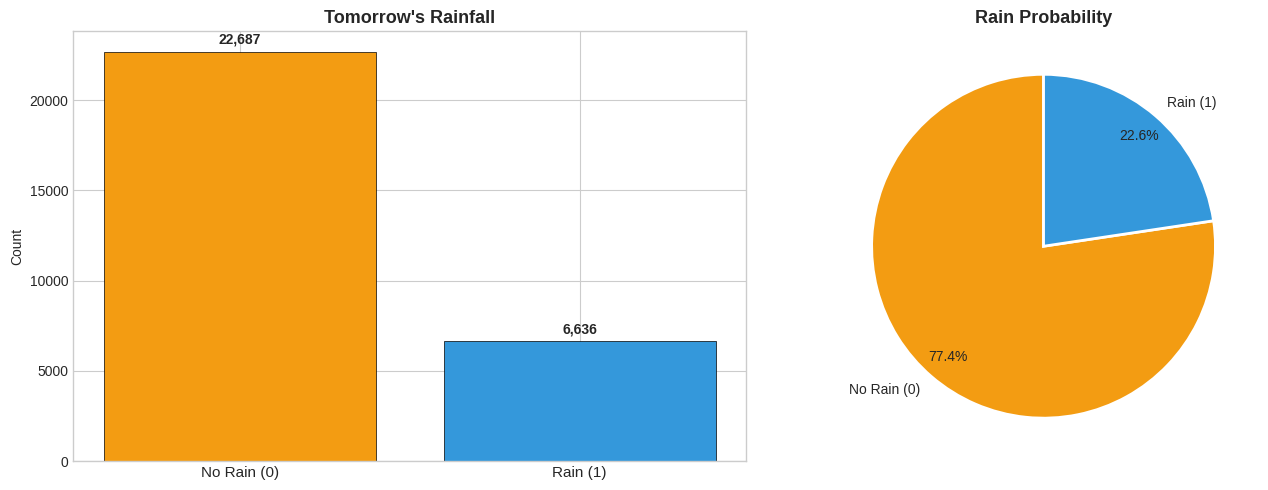

AU context: BOM provides forecasts for 700+ locations across Australia.
Rainfall prediction is critical for agriculture ($65B sector) and flood management.
BOM's ACCESS model is Australia's primary numerical weather prediction system.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['No Rain (0)', 'Rain (1)']
colors = ['#f39c12', '#3498db']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('Tomorrow\'s Rainfall', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + max(vc.values)*0.02, f'{v:,}', ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Rain Probability', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: BOM provides forecasts for 700+ locations across Australia.")
print("Rainfall prediction is critical for agriculture ($65B sector) and flood management.")
print("BOM's ACCESS model is Australia's primary numerical weather prediction system.")


## 3. Exploratory Data Analysis

Numeric features (16): ['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine', 'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm', 'Pressure9am', 'Pressure3pm']


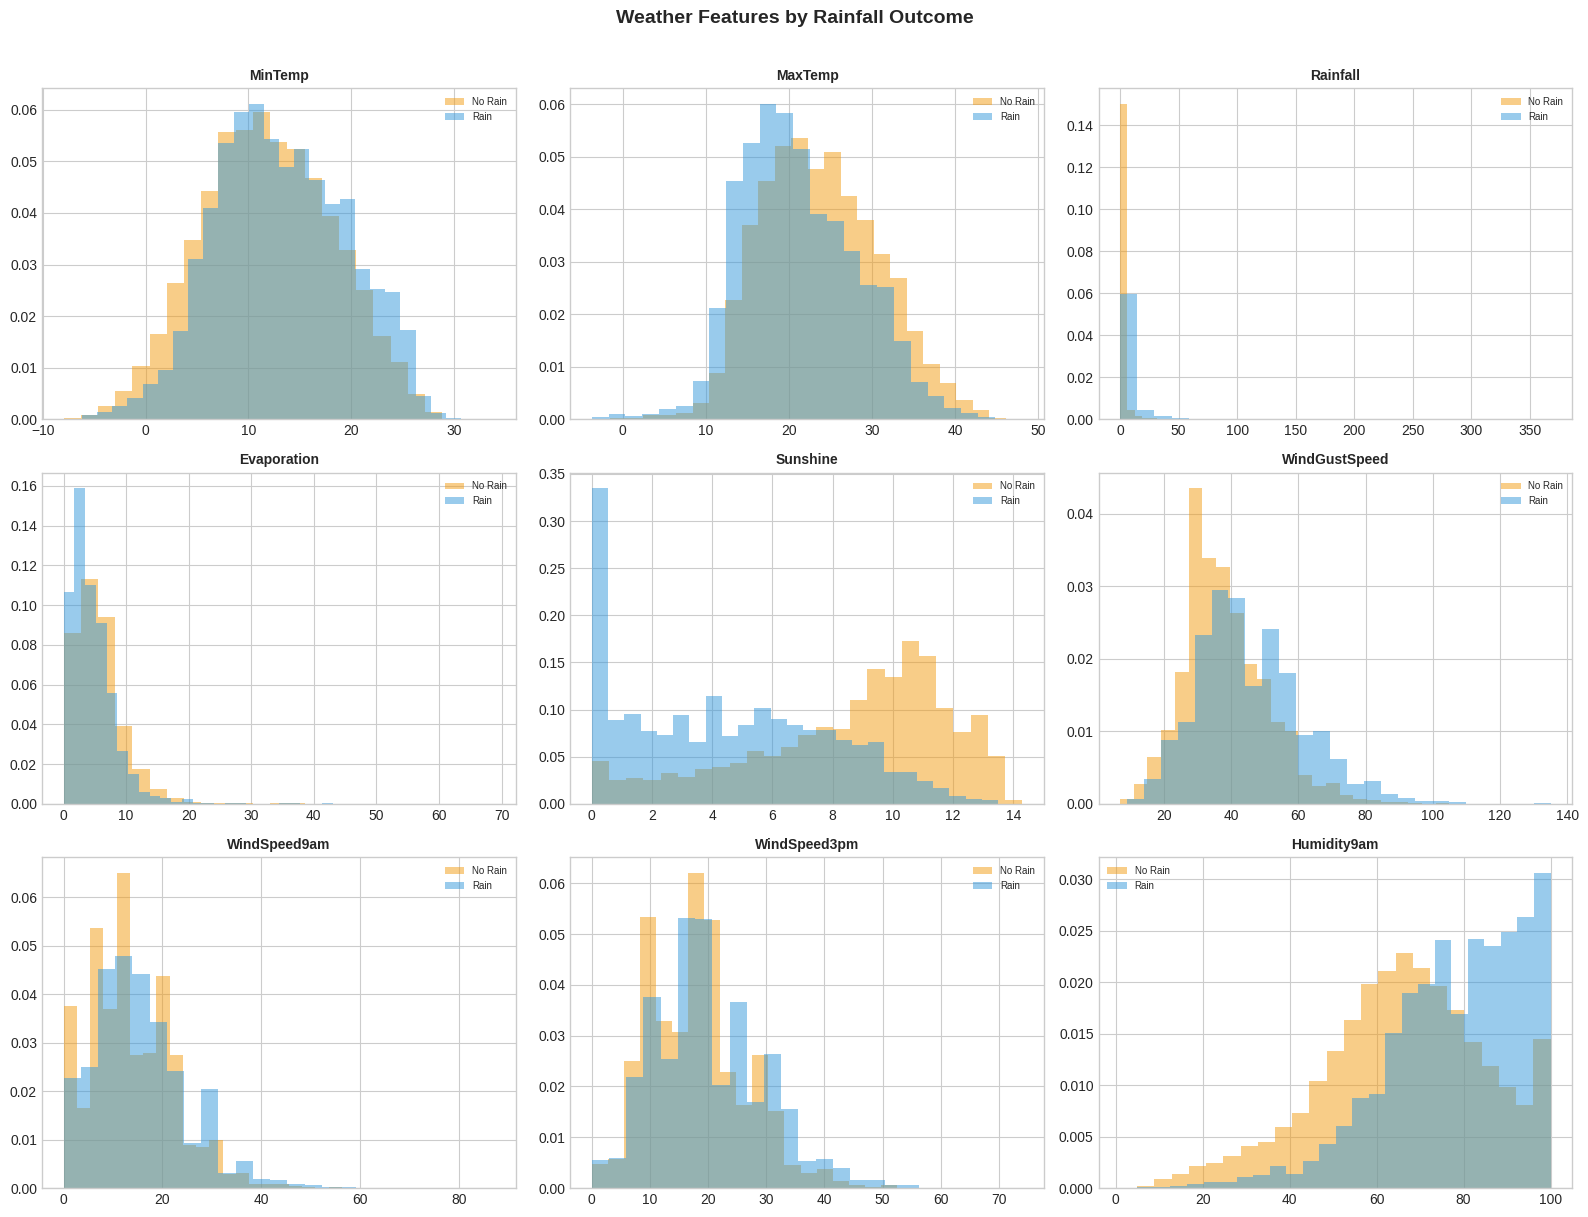

In [6]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols[:12]}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#f39c12', '#3498db'], ['No Rain', 'Rain']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Weather Features by Rainfall Outcome', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday']


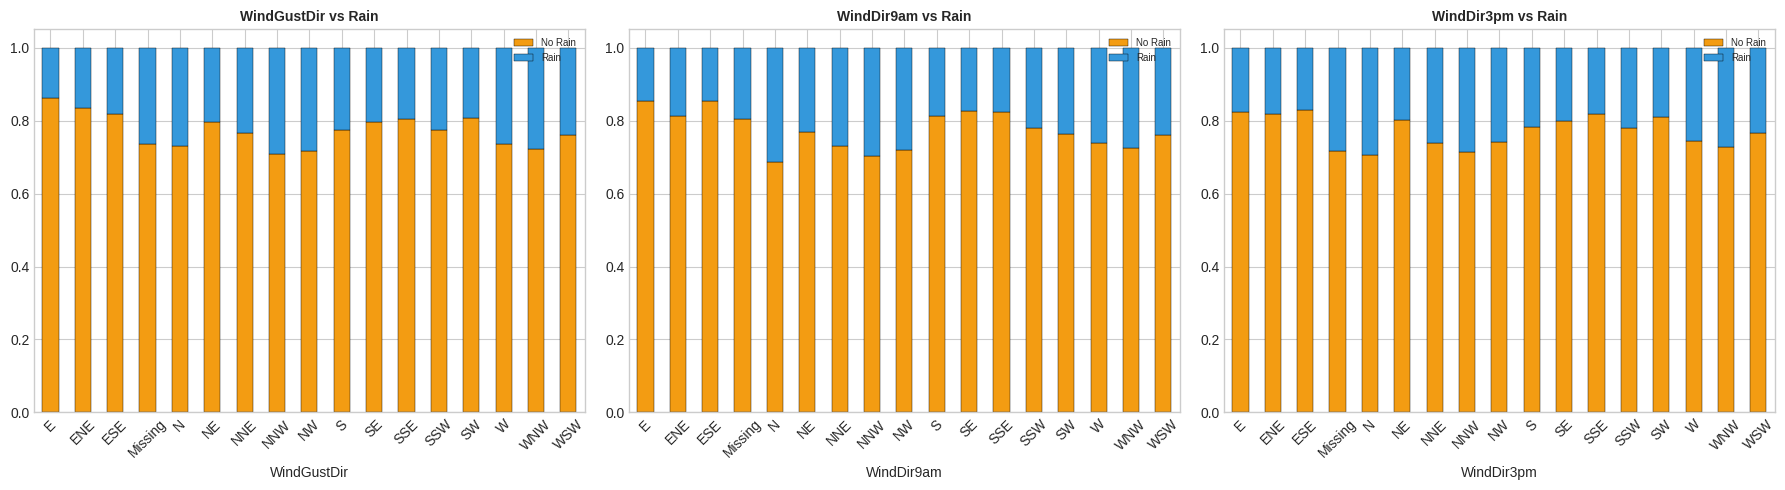

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 16 and 'date' not in c.lower()
            and 'location' not in c.lower()]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    fig, axes = plt.subplots(1, min(len(cat_cols), 3), figsize=(6 * min(len(cat_cols), 3), 5))
    if not isinstance(axes, np.ndarray): axes = [axes]
    for i, col in enumerate(cat_cols[:3]):
        ct = pd.crosstab(df[col].fillna('Missing'), df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#f39c12', '#3498db'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs Rain', fontsize=10, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['No Rain', 'Rain'], fontsize=7)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


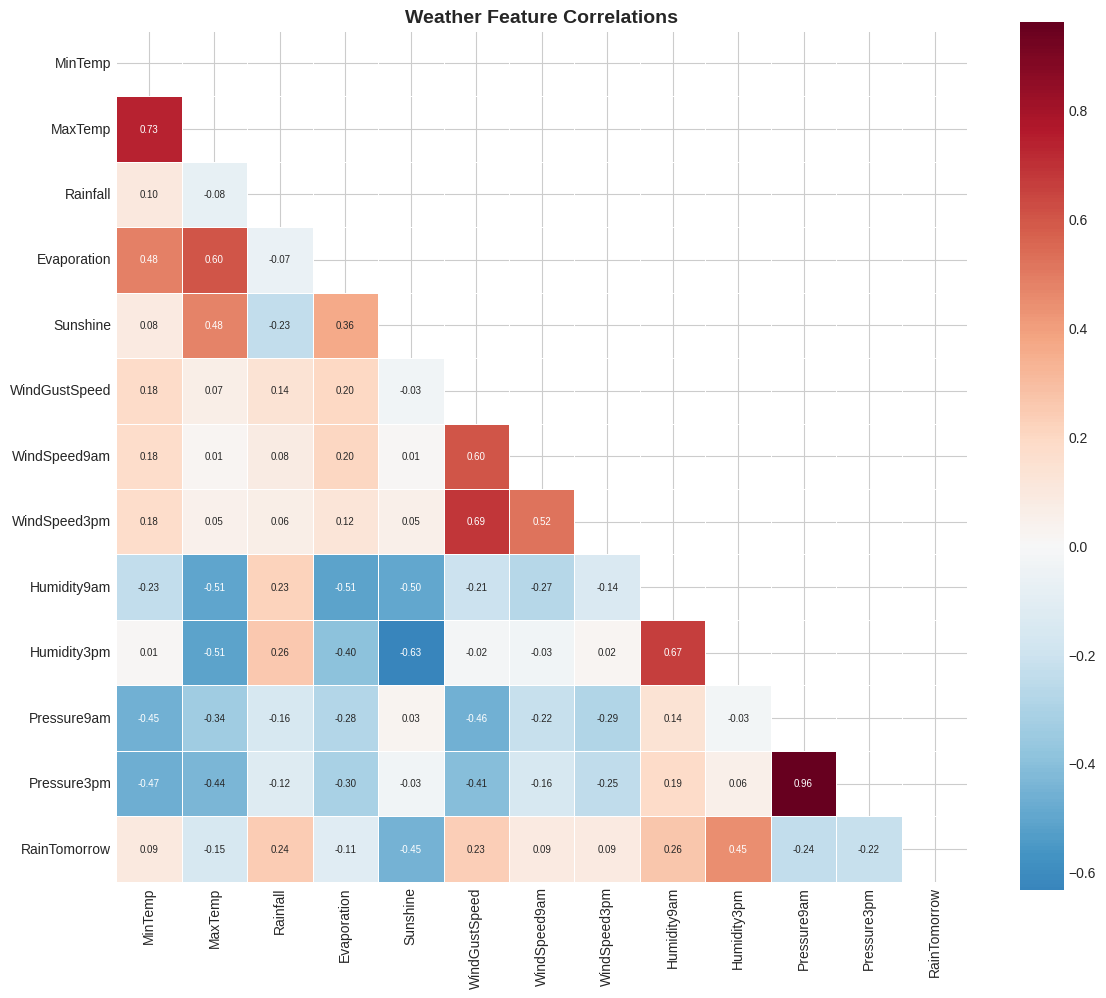

In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:12] + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Weather Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop date and location (too many unique values)
drop_cols = [c for c in df_model.columns if c.lower() in ['date', 'unnamed: 0', 'index', 'id']]
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col and df_model[col].nunique() > 30:
        drop_cols.append(col)

# Drop RainToday leakage check — it's legitimate (today's rain predicts tomorrow's)
# Keep it as a feature

drop_cols = list(set(drop_cols))
if drop_cols:
    df_model.drop(columns=[c for c in drop_cols if c in df_model.columns], inplace=True)
    print(f"Dropped: {drop_cols}")

# Encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Impute
if X.isnull().sum().sum() > 0:
    print(f"\nImputing {X.isnull().sum().sum()} missing values...")
    X = X.fillna(X.median())

# Feature engineering
composites_added = []

# Temperature range
temp_min = [c for c in X.columns if c.lower() in ['mintemp', 'temp_min']]
temp_max = [c for c in X.columns if c.lower() in ['maxtemp', 'temp_max']]
if temp_min and temp_max:
    X['temp_range'] = X[temp_max[0]] - X[temp_min[0]]
    composites_added.append('temp_range')
    print("Created 'temp_range'")

# Humidity change
hum_9 = [c for c in X.columns if c.lower() in ['humidity9am']]
hum_3 = [c for c in X.columns if c.lower() in ['humidity3pm']]
if hum_9 and hum_3:
    X['humidity_drop'] = X[hum_9[0]] - X[hum_3[0]]
    composites_added.append('humidity_drop')
    print("Created 'humidity_drop' (9am - 3pm)")

# Pressure change
pres_9 = [c for c in X.columns if c.lower() in ['pressure9am']]
pres_3 = [c for c in X.columns if c.lower() in ['pressure3pm']]
if pres_9 and pres_3:
    X['pressure_change'] = X[pres_3[0]] - X[pres_9[0]]
    composites_added.append('pressure_change')
    print("Created 'pressure_change' (3pm - 9am)")

# High humidity flag
if hum_3:
    X['high_humidity'] = (X[hum_3[0]] > 70).astype(int)
    composites_added.append('high_humidity')
    print("Created 'high_humidity' (3pm > 70%)")

print(f"\nEngineered: {len(composites_added)}")
print(f"Final: {X.shape}")


Dropped: ['Location', 'Date']
  Encoded 'WindGustDir': 17 classes
  Encoded 'WindDir9am': 17 classes
  Encoded 'WindDir3pm': 17 classes
  Encoded 'RainToday': 3 classes

Imputing 59658 missing values...
Created 'temp_range'
Created 'humidity_drop' (9am - 3pm)
Created 'pressure_change' (3pm - 9am)
Created 'high_humidity' (3pm > 70%)

Engineered: 4
Final: (29323, 24)


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'f1_mean': np.mean(fold_f1),
        'auc_mean': np.mean(fold_auc), 'precision_mean': np.mean(fold_prec),
        'recall_mean': np.mean(fold_rec), 'brier_mean': np.mean(fold_brier),
        'time': elapsed, 'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=0.8362  F1=0.5750  AUC=0.8601
  Fold 2: Acc=0.8438  F1=0.5907  AUC=0.8711
  Fold 3: Acc=0.8394  F1=0.5764  AUC=0.8534
  -- Acc: 0.8398  F1: 0.5807  AUC: 0.8616  Time: 79.76s

Training: Random Forest
  Fold 1: Acc=0.8436  F1=0.5871  AUC=0.8704
  Fold 2: Acc=0.8507  F1=0.5988  AUC=0.8836
  Fold 3: Acc=0.8422  F1=0.5768  AUC=0.8635
  -- Acc: 0.8455  F1: 0.5876  AUC: 0.8725  Time: 6.44s

Training: XGBoost
  Fold 1: Acc=0.8434  F1=0.6079  AUC=0.8724
  Fold 2: Acc=0.8514  F1=0.6275  AUC=0.8811
  Fold 3: Acc=0.8404  F1=0.5988  AUC=0.8650
  -- Acc: 0.8451  F1: 0.6114  AUC: 0.8728  Time: 1.11s

Training: LightGBM
  Fold 1: Acc=0.8455  F1=0.6080  AUC=0.8784
  Fold 2: Acc=0.8571  F1=0.6374  AUC=0.8918
  Fold 3: Acc=0.8447  F1=0.6047  AUC=0.8737
  -- Acc: 0.8491  F1: 0.6167  AUC: 0.8813  Time: 1.26s


## 6. Model Comparison & Selection

In [12]:
summary_rows = [{'Model': mn, 'Accuracy': f"{res['accuracy_mean']:.4f}",
    'F1': f"{res['f1_mean']:.4f}", 'ROC-AUC': f"{res['auc_mean']:.4f}",
    'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
    'AUC_val': res['auc_mean']} for mn, res in results.items()]
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 90)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 90)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model Accuracy     F1 ROC-AUC  Brier   Time
           LightGBM   0.8491 0.6167  0.8813 0.1072  1.26s
            XGBoost   0.8451 0.6114  0.8728 0.1114  1.11s
      Random Forest   0.8455 0.5876  0.8725 0.1103  6.44s
Logistic Regression   0.8398 0.5807  0.8616 0.1145 79.76s

Best model: LightGBM


## 7. Error Analysis & Threshold Tuning

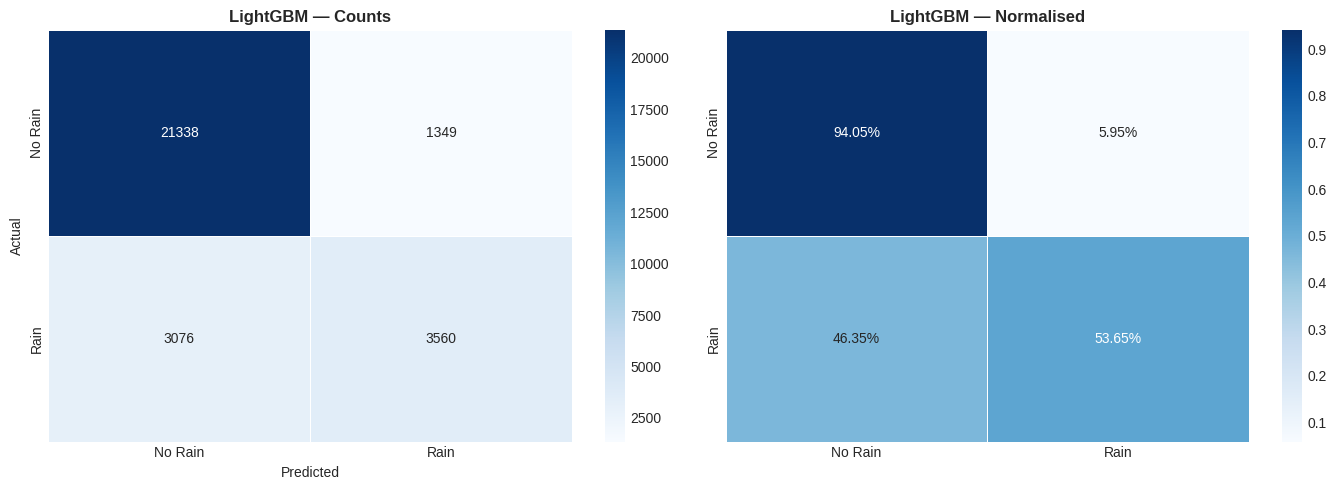


              precision    recall  f1-score   support

     No Rain       0.87      0.94      0.91     22687
        Rain       0.73      0.54      0.62      6636

    accuracy                           0.85     29323
   macro avg       0.80      0.74      0.76     29323
weighted avg       0.84      0.85      0.84     29323



In [13]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No Rain', 'Rain']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


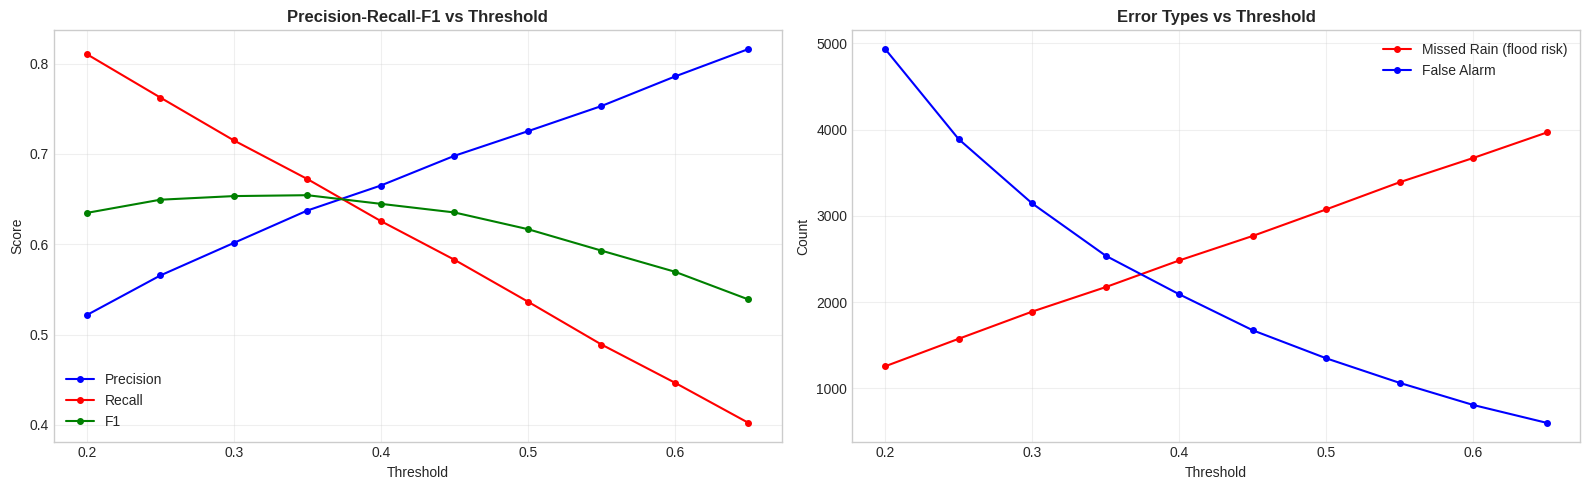


Optimal threshold (F1): 0.35
For flood safety, lower threshold recommended — missing rain is more dangerous than false alarms.


In [14]:
thresholds = np.arange(0.20, 0.70, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed Rain (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Alarm (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed Rain (FN)'], 'r-o', ms=4, label='Missed Rain (flood risk)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Alarm (FP)'], 'b-o', ms=4, label='False Alarm')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")
print("For flood safety, lower threshold recommended — missing rain is more dangerous than false alarms.")


## 8. Feature Importance & Policy Insights

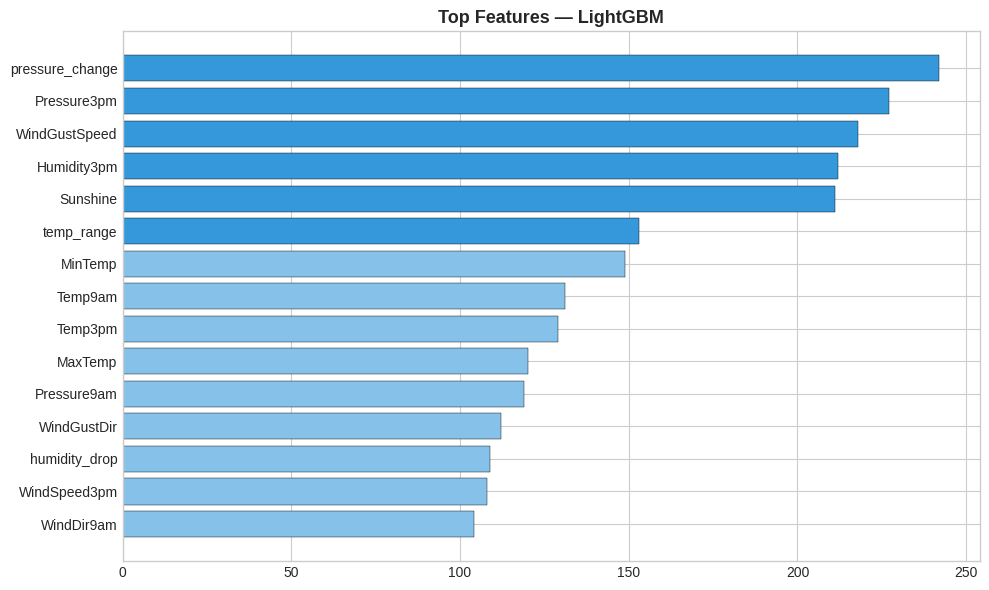

TOP 5 RAINFALL PREDICTORS
  pressure_change            242.0000
  Pressure3pm                227.0000
  WindGustSpeed              218.0000
  Humidity3pm                212.0000
  Sunshine                   211.0000

Meteorology insight: Humidity and pressure are the strongest rainfall predictors.
3pm readings are more predictive than 9am — afternoon conditions drive next-day weather.


In [15]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    plot_imp = feat_imp.tail(15)
    fig, ax = plt.subplots(figsize=(10, max(6, len(plot_imp) * 0.4)))
    colors_imp = ['#3498db' if imp > feat_imp['Importance'].quantile(0.75) else '#85c1e9' for imp in plot_imp['Importance']]
    ax.barh(plot_imp['Feature'], plot_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Top Features — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 RAINFALL PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")
    print("\nMeteorology insight: Humidity and pressure are the strongest rainfall predictors.")
    print("3pm readings are more predictive than 9am — afternoon conditions drive next-day weather.")


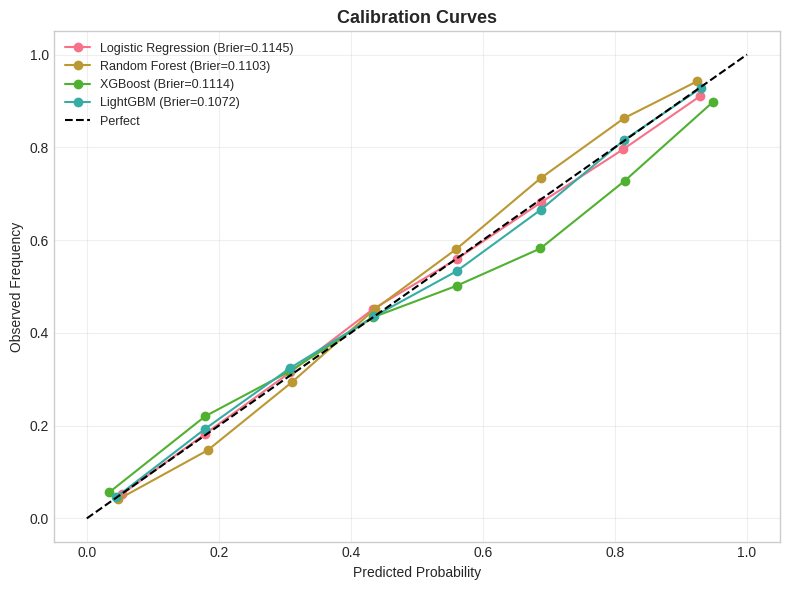

In [16]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness

In [17]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.50': best_res['f1_mean'] > 0.50,
    'Brier < 0.15': best_res['brier_mean'] < 0.15,
    'Training time < 120s': best_res['time'] < 120,
    'Cross-validated': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    LightGBM
  ROC-AUC:              0.8813
  F1:                   0.6167
  Precision:            0.7252
  Recall:               0.5365
  Brier Score:          0.1072
  Training time:        1.3s
  Feature count:        24
  Dataset rows:         29,323
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.35

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.80
  [pass] F1 > 0.50
  [pass] Brier < 0.15
  [pass] Training time < 120s
  [pass] Cross-validated
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [18]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: BOM Automatic Weather Stations, radar, satellite, ACCESS model
   Ingestion: BOM API -> Azure IoT Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (observations, forecasts, climate normals)
   Schedule: Hourly observations + 6-hourly forecast cycles

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Hourly rainfall probability updates per location
   Output: Rain probability + confidence + contributing weather factors
   Dashboard: Power BI (national rainfall probability map)

3. INTEGRATION POINTS
   BOM: Supplement numerical weather prediction models
   Agriculture: Farm decision support (planting, harvesting, irrigation)
   Emergency Mgmt: Flood warning system input
   Water authorities: Dam inflow forecasting, water restriction decisions
   Transport: Road condition and aviation weather planning

4. GOVERNANCE
   BOM standards: WMO forecast verification methodology
   Validation: Against actual rainfall gauge measurements
   Transparency: Forecast accuracy published in BOM Annual Report
   Safety: Conservative threshold for flood/severe weather warnings
   Public trust: ML supplements but never replaces meteorologist judgment

5. MONITORING & RETRAINING
   Drift: PSI on weather features monthly
   Performance: Brier score against actual rainfall daily
   Retraining: Seasonal with latest observation data
   Climate change: Adjust baselines for shifting climate normals
   El Nino/La Nina: Separate models for ENSO phases

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: BOM Automatic Weather Stations, radar, satellite, ACCESS model
   Ingestion: BOM API -> Azure IoT Hub -> Microsoft Fabric Lakehouse
   Feature store: Fabric gold layer (observations, forecasts, climate normals)
   Schedule: Hourly observations + 6-hourly forecast cycles

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Hourly rainfall probability updates per location
   Output: Rain probability + confidence + contributing weather factors
   Dashboard: Power BI (national rainfall probability map)

3. INTEGRATION POINTS
   BOM: Supplement numerical weather prediction models
   Agriculture: Farm decision support (planting, harvesting, irrigation)
   Emergency Mgmt: Flood warning system input
   Water authorities: Dam inflow forecasting, water restriction decisions
   Transport: Road condition and aviation weather planning

4. GOVERNANCE
   BOM standards: WMO forecast verification methodology
   Validation: 